# Tiny_Tau_v4.5 – 3-Qubit Extension: KK Tower Ladder
Purpose
Extend the 2-qubit mini KK tower to 3 qubits for a more realistic Kaluza-Klein ladder simulation in the compact S¹ dimension (τ = 7 h⁻¹ Mpc).
This allows probing higher harmonics, entanglement effects, and potential resonance graph patterns in Tav topology.
Setup details

Qubits: 3 (expanded tower)
Ansatz: n_local RY rotations + CX entanglement, linear topology, reps=2
Tau harmonics: rz(2π/7) on q0, rz(4π/7) on q1, rz(6π/7) on q2 (harmonic series)
Hamiltonian: Z on each qubit (potentials) + XX correlations (asymmetry between consecutive modes)
Berard: optional ry(1.054) on q2 for modulation (comment out if not needed)

Expected outcomes

8 possible outcomes (000 to 111) → richer correlations and phase-sensitive patterns
Check for directional bias (e.g., toward 111) or resonance in even/odd modes
Compare to 2-qubit: more qubits should show more tunable asymmetry

v4.5 goals

Run baseline 3-qubit with positive harmonics
Test negative phase on q0
Add Berard on q2 → observe modulation
Analyze 8-outcome probabilities for correlated bias or tower effects

"Higher harmonics in the compact circle may reveal resonance graph structures, with entanglement amplifying topological asymmetry."
Next immediate step: Run baseline 3-qubit model with positive harmonics.

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.circuit.library import n_local
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
import numpy as np
from qiskit.visualization import plot_histogram
simulator = AerSimulator(method='statevector')
estimator = StatevectorEstimator()
optimizer = COBYLA(maxiter=150)  # Increased maxiter for 3 qubits (deeper circuit)
print("3-qubit environment ready")

3-qubit environment ready


In [2]:
hamiltonian_3q = SparsePauliOp.from_list([
("ZII", 1.0), ("IZI", 1.0), ("IIZ", 1.0),  # Potentials on each qubit
("XXI", 0.142857), ("IXX", 0.142857)      # Correlated XX asymmetry between consecutive modes
])
print("3-qubit Hamiltonian:", hamiltonian_3q)

3-qubit Hamiltonian: SparsePauliOp(['ZII', 'IZI', 'IIZ', 'XXI', 'IXX'],
              coeffs=[1.      +0.j, 1.      +0.j, 1.      +0.j, 0.142857+0.j, 0.142857+0.j])


In [3]:
ansatz_3q = n_local(
num_qubits=3,
rotation_blocks='ry',
entanglement_blocks=['cx'],
reps=2,
entanglement='linear'
)

In [4]:
ansatz_3q.rz(2 * np.pi / 7, 0)  # Fundamental on q0
ansatz_3q.rz(4 * np.pi / 7, 1)  # Next on q1
ansatz_3q.rz(6 * np.pi / 7, 2)  # Next on q2

In [5]:
print("3-qubit ansatz created with Tau ladder")
print("Number of parameters:", ansatz_3q.num_parameters)

3-qubit ansatz created with Tau ladder
Number of parameters: 9


In [6]:
vqe_3q = VQE(
estimator=estimator,
ansatz=ansatz_3q,
optimizer=optimizer
)
result_3q = vqe_3q.compute_minimum_eigenvalue(operator=hamiltonian_3q)
print(f"3-qubit energy: {result_3q.eigenvalue.real:.6f}")
print("Optimal parameters:", result_3q.optimal_parameters)

3-qubit energy: -3.003498
Optimal parameters: {ParameterVectorElement(θ[0]): np.float64(6.204129682167984), ParameterVectorElement(θ[1]): np.float64(3.0059992547556003), ParameterVectorElement(θ[2]): np.float64(-1.8380186474790838), ParameterVectorElement(θ[3]): np.float64(4.392527092370686), ParameterVectorElement(θ[4]): np.float64(1.5297238662038113), ParameterVectorElement(θ[5]): np.float64(-0.28204128940192463), ParameterVectorElement(θ[6]): np.float64(1.2407258143663906), ParameterVectorElement(θ[7]): np.float64(-4.808606769097023), ParameterVectorElement(θ[8]): np.float64(-1.602561699659025)}


High-shot 3-qubit counts: {'001': 1, '100': 11, '010': 2, '111': 16370}


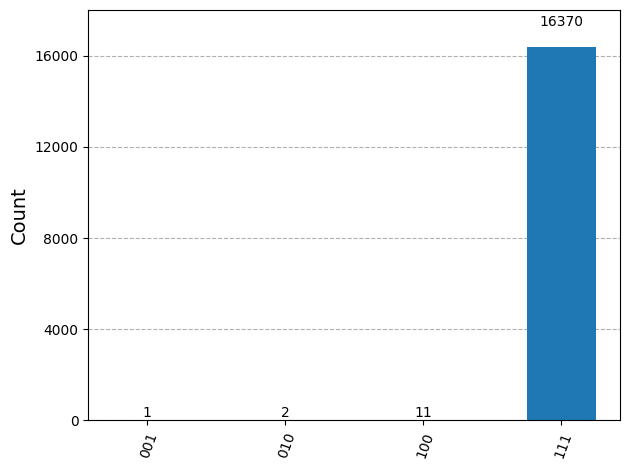

In [7]:
qc_3q = ansatz_3q.assign_parameters(result_3q.optimal_parameters)
qc_3q.measure_all()
counts_3q = simulator.run(qc_3q, shots=16384).result().get_counts()
print("High-shot 3-qubit counts:", counts_3q)
plot_histogram(counts_3q)

In [8]:
from qiskit import QuantumCircuit
import numpy as np

# Create 3-qubit circuit with circular entanglement
qc = QuantumCircuit(3)

# Superposition on q0 to seed entanglement
qc.h(0)

# Circular entanglement: q0-q1, q1-q2, q2-q0 (ring topology)
qc.cx(0, 1)   # q0 controls q1
qc.cx(1, 2)   # q1 controls q2
qc.cx(2, 0)   # wrap-around: q2 controls q0 (closes the ring)

# Optional: add Tau-inspired harmonic phases around the circle
# (mimicking periodic boundary conditions of compact S¹)
qc.rz(2 * np.pi / 7, 0)   # fundamental mode on q0
qc.rz(4 * np.pi / 7, 1)   # next harmonic on q1
qc.rz(6 * np.pi / 7, 2)   # next on q2

# Measure all
qc.measure_all()

# Print and draw the circuit
print("3-qubit circular entanglement circuit with Tau phases:")
print(qc.draw(fold=-1))  # fold=-1 shows full width

3-qubit circular entanglement circuit with Tau phases:
        ┌───┐          ┌───┐┌──────────┐ ░ ┌─┐      
   q_0: ┤ H ├──■───────┤ X ├┤ Rz(2π/7) ├─░─┤M├──────
        └───┘┌─┴─┐     └─┬─┘├──────────┤ ░ └╥┘┌─┐   
   q_1: ─────┤ X ├──■────┼──┤ Rz(4π/7) ├─░──╫─┤M├───
             └───┘┌─┴─┐  │  ├──────────┤ ░  ║ └╥┘┌─┐
   q_2: ──────────┤ X ├──■──┤ Rz(6π/7) ├─░──╫──╫─┤M├
                  └───┘     └──────────┘ ░  ║  ║ └╥┘
meas: 3/════════════════════════════════════╩══╩══╩═
                                            0  1  2 


Counts: {'000': 8111, '110': 8273}


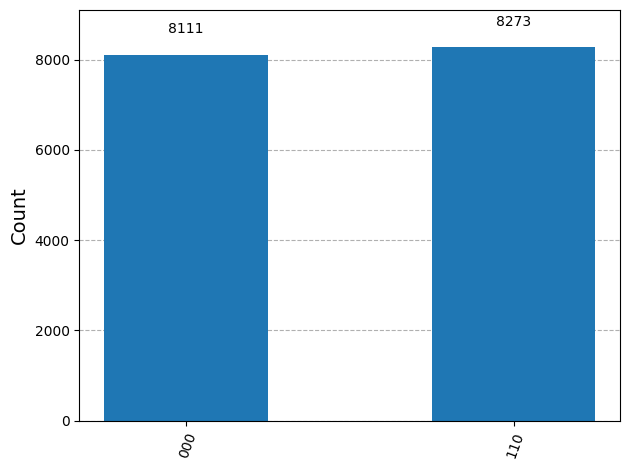

In [9]:
from qiskit_aer import AerSimulator

sim = AerSimulator()
result = sim.run(qc, shots=16384).result()
counts = result.get_counts()

print("Counts:", counts)
plot_histogram(counts)

High-shot counts (3-qubit circular ring with Tau phases):
{'000': 8280, '110': 8104}


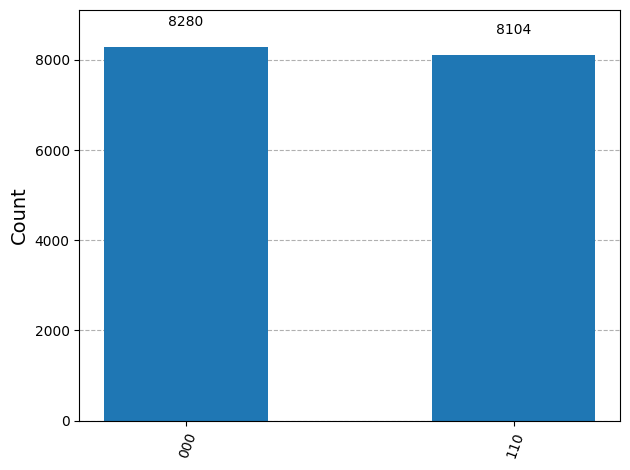

In [10]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Use the circuit you just built (qc)
sim = AerSimulator()
result = sim.run(qc, shots=16384).result()
counts = result.get_counts()

print("High-shot counts (3-qubit circular ring with Tau phases):")
print(counts)

# Plot
plot_histogram(counts)

High-shot counts (circular ring + Tau phases + Berard):
{'110': 8206, '000': 8178}


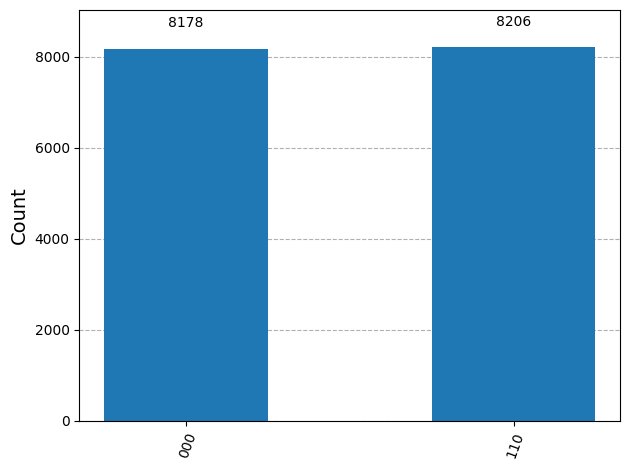

In [11]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

sim = AerSimulator()
result = sim.run(qc, shots=16384).result()
counts = result.get_counts()

print("High-shot counts (circular ring + Tau phases + Berard):")
print(counts)

plot_histogram(counts)

In [12]:
from qiskit import QuantumCircuit
import numpy as np

# ────────────────────────────────────────────────
# 3-qubit Circular Ring + Tau phases + Berard on every qubit
# ────────────────────────────────────────────────

qc = QuantumCircuit(3)

# Superposition seed (can be on all for more balance)
qc.h([0, 1, 2])  # H on every qubit → full initial superposition

# Circular entanglement (ring topology)
qc.cx(0, 1)   # q0 → q1
qc.cx(1, 2)   # q1 → q2
qc.cx(2, 0)   # q2 → q0 (closes the ring)

# Tau harmonics around the circle (1/7 multiples)
qc.rz(2 * np.pi / 7, 0)   # mode 1 on q0
qc.rz(4 * np.pi / 7, 1)   # mode 2 on q1
qc.rz(6 * np.pi / 7, 2)   # mode 3 on q2

# Berard rotation on EVERY qubit – symmetric distribution
berard_angle = 1.054
qc.ry(berard_angle, 0)
qc.ry(berard_angle, 1)
qc.ry(berard_angle, 2)

# Measure all
qc.measure_all()

# Print and draw
print("3-qubit circular ring with Tau harmonics + Berard on every qubit:")
print(qc.draw(fold=-1))  # full width

3-qubit circular ring with Tau harmonics + Berard on every qubit:
        ┌───┐          ┌───┐┌──────────┐┌───────────┐ ░ ┌─┐      
   q_0: ┤ H ├──■───────┤ X ├┤ Rz(2π/7) ├┤ Ry(1.054) ├─░─┤M├──────
        ├───┤┌─┴─┐     └─┬─┘├──────────┤├───────────┤ ░ └╥┘┌─┐   
   q_1: ┤ H ├┤ X ├──■────┼──┤ Rz(4π/7) ├┤ Ry(1.054) ├─░──╫─┤M├───
        ├───┤└───┘┌─┴─┐  │  ├──────────┤├───────────┤ ░  ║ └╥┘┌─┐
   q_2: ┤ H ├─────┤ X ├──■──┤ Rz(6π/7) ├┤ Ry(1.054) ├─░──╫──╫─┤M├
        └───┘     └───┘     └──────────┘└───────────┘ ░  ║  ║ └╥┘
meas: 3/═════════════════════════════════════════════════╩══╩══╩═
                                                         0  1  2 


High-shot counts (circular ring + Tau + Berard on all qubits):
{'100': 471, '110': 314, '010': 2722, '000': 4041, '001': 13284, '111': 1099, '011': 9158, '101': 1679}


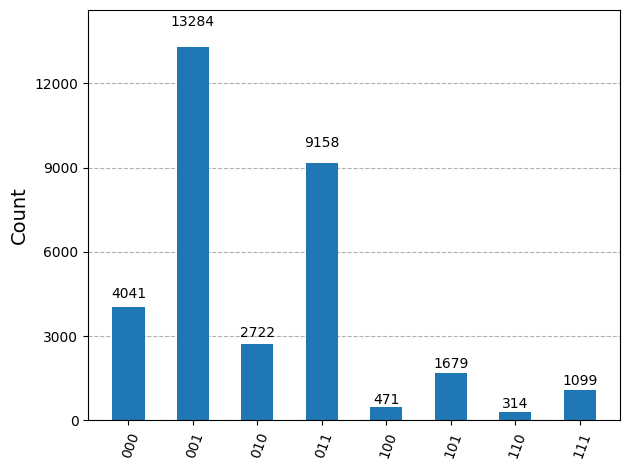

In [13]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

sim = AerSimulator()
result = sim.run(qc, shots=32768).result()  # more shots for precision
counts = result.get_counts()

print("High-shot counts (circular ring + Tau + Berard on all qubits):")
print(counts)

plot_histogram(counts)

In [ ]:
from qiskit import QuantumCircuit
import numpy as np
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# ────────────────────────────────────────────────
# 21-qubit Circular Ring Extension with Tau Phases
# ────────────────────────────────────────────────
n = 21  # qubits
qc = QuantumCircuit(n)

# Superposition seed on q0
qc.h(0)

# Circular entanglement: chain + wrap-around
for i in range(n - 1):
    qc.cx(i, i+1)
qc.cx(n-1, 0)  # wrap-around to close the ring

# Tau-inspired harmonic phases around the ring (1/7 multiples, cycled)
for i in range(n):
    k = (i % 7) + 1  # cycle through 1 to 7
    qc.rz(2 * np.pi * k / 7, i)

# Measure all
qc.measure_all()

# Simulate with shots (fast, approximate probabilities)
sim = AerSimulator()
result = sim.run(qc, shots=4096).result()  # increase shots if needed
counts = result.get_counts()

# Print counts
print("High-shot counts (21-qubit circular ring with Tau phases):")
print(counts)

# Plot histogram
plot_histogram(counts)

# Optional: top 5 states for text summary
top_states = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 states:")
for state, count in top_states:
    print(f"{state}: {count} ({count/4096*100:.1f}%)")